In [1]:
import shap
import numpy as np
import pandas as pd
import optuna
from main import load_model_from_study

import torch.nn as nn
import torch
from src.dataset import _pad_sequence
from src.dataset import YelpDataset

from torch.utils.data import DataLoader


c:\Users\n01715077\AppData\Local\miniconda3\envs\adl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
# Optuna variables
study_name="sentiment_lstm_hpo"
direction="minimize"
storage="sqlite:///./models/sentiment_lstm_hpo.db"

# Load the optuna study
study = optuna.load_study(study_name=study_name, storage=storage)

In [4]:
model = load_model_from_study(study)
loss_fn = nn.CrossEntropyLoss()

In [5]:
class SentimentWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x):
        return self.model(x)

### Prepare inital sample to estimate Shap values

In [6]:
df = pd.DataFrame()
df2 = pd.DataFrame()

df['x'] = np.load('./data/X_1.npy', allow_pickle=True)[:100]
df['y'] = np.load('./data/y_1.npy')[:100]


df2['x'] = np.load('./data/X_1.npy', allow_pickle=True)[100:150]
df2['y'] = np.load('./data/y_1.npy')[100:150]

In [7]:
background_dataset = YelpDataset(df['x'], df['y'], 100)
background_loader = DataLoader(background_dataset, 100)

test_dataset = YelpDataset(df2['x'], df2['y'], 100)
test_loader = DataLoader(test_dataset, 50)

In [ ]:
for b in background_loader:
    x = b['feature'].to(DEVICE)
    explainer = shap.KernelExplainer(model, x)

In [9]:
import matplotlib.pyplot as plt

<class 'numpy.ndarray'>
(50, 100, 300, 3)


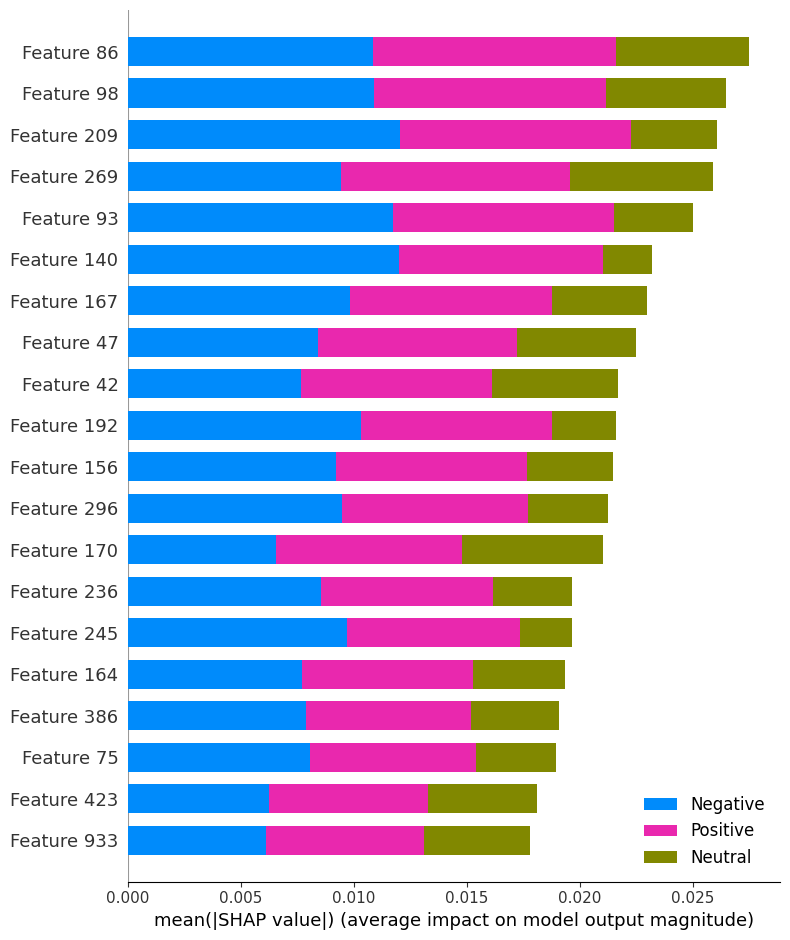

In [12]:
# This cell replaces your problematic cell with a fixed implementation
for b in test_loader:
    model.train()  # Make sure the model is in evaluation mode
    x2 = b['feature'].to(DEVICE)
    shap_values = explainer.shap_values(x2, check_additivity=False)
    model.eval()
    print(type(shap_values))
    print(np.array(shap_values).shape)  # Shape: (50, 100, 300, 3)
    
    # Convert PyTorch tensor to numpy
    x2_numpy = x2.cpu().detach().numpy()
    
    # Flatten the input for visualization
    x2_flat = x2_numpy.reshape(x2_numpy.shape[0], -1)  # Shape: (50, 30000)
    
    # Reorganize SHAP values to get a list of arrays per class
    # Target shape: list of 3 arrays, each with shape (50, 30000)
    num_classes = 3
    shap_values_by_class = []
    
    # Reshape the SHAP values to be organized by class
    for class_idx in range(num_classes):
        # Extract values for this class and flatten sequence and embedding dimensions
        class_values = shap_values[:, :, :, class_idx].reshape(shap_values.shape[0], -1)
        shap_values_by_class.append(class_values)
    
    # Now plot for all classes
    plt.figure(figsize=(12, 8))
    class_names = ['Negative', 'Neutral', 'Positive']  # Replace with your actual class names
    shap.summary_plot(shap_values_by_class, x2_flat, class_names=class_names)
    plt.tight_layout()
    plt.savefig('shap_summary_all_classes.png')
    plt.close()
    